In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("..")
print(os.getcwd(), os.listdir())

C:\Users\an.v.potapov\Desktop\учеба\ФТИАД\курсач\gan_moex ['.git', '.gitignore', '.idea', '.ipynb_checkpoints', '.pytest_cache', 'AIRI', 'compare with airi', 'dashboard', 'data', 'genrisk', 'library', 'lightning_logs', 'models', 'README.MD', 'research', 'setup.py', 'test.egg-info', 'TSGBench', 'wandb']


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from torch import optim
import torch
import pandas as pd
import numpy as np
import wandb

from library.constants import DEVICE, WINDOW_SIZE
from library.generation import generate_samples
from library.dataset import ReturnsDataset
from library.gan_train_loop import train_gan
from library.gan import Discriminator, Generator
from library.generation import generate_fake_returns
from library.gan_train_loop import load_gan

In [4]:
from library.dataset import get_pytorch_datataset, BATCH_SIZE

df_returns_real, dataset, dataloader, N_ASSETS, WINDOW_SIZE = get_pytorch_datataset()

print(f'\nDataset length: {len(dataset)}')
print(f'Number of assets: {N_ASSETS}')
sample_batch = next(iter(dataloader))
assert sample_batch.size() == (BATCH_SIZE, N_ASSETS, WINDOW_SIZE)
print(f'Sample batch: {sample_batch.size()}')

AAAAAAA data True data\tickers.csv True
Chosen tickers: ['LKOH', 'SBER', 'SBERP', 'VTBR', 'MOEX']
Length before dropping NaNs: 2603
Length after dropping NaNs: 2577

Dataset length: 2451
Number of assets: 5
Sample batch: torch.Size([256, 5, 126])


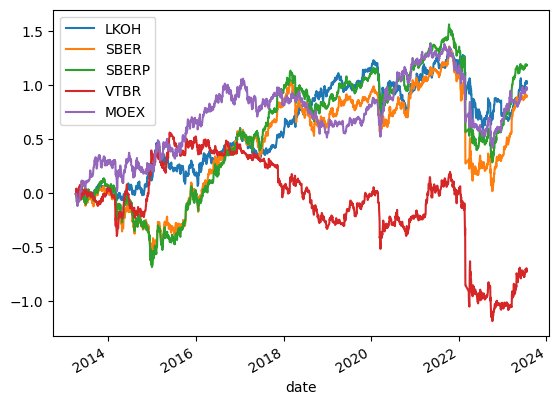

In [5]:
df_returns_real.cumsum().plot()
plt.show()

In [6]:
from library.constants import DEVICE

print(f'Use device: {DEVICE}')

Use device: cpu


C:\Python\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  0%|          | 0/100 [00:00<?, ?it/s]

100 epochs train time: 276.8s. Estimated train time: 0.0m
Fake std: [0.46778554 0.43123877 0.45030975 0.58464617 0.3912145 ].
Real std: [0.01934618 0.02320357 0.02170969 0.02256658 0.01871406]
Fake correlation: -0.6118077113730006. Real correlation: 0.9185647795211369


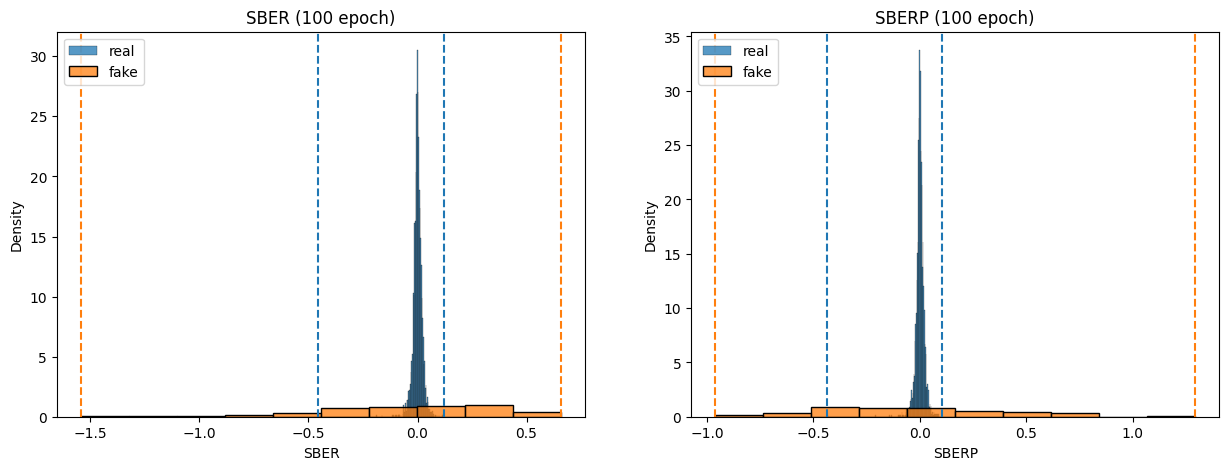

C:\Python\Lib\site-packages\numpy\core\fromnumeric.py:3502: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


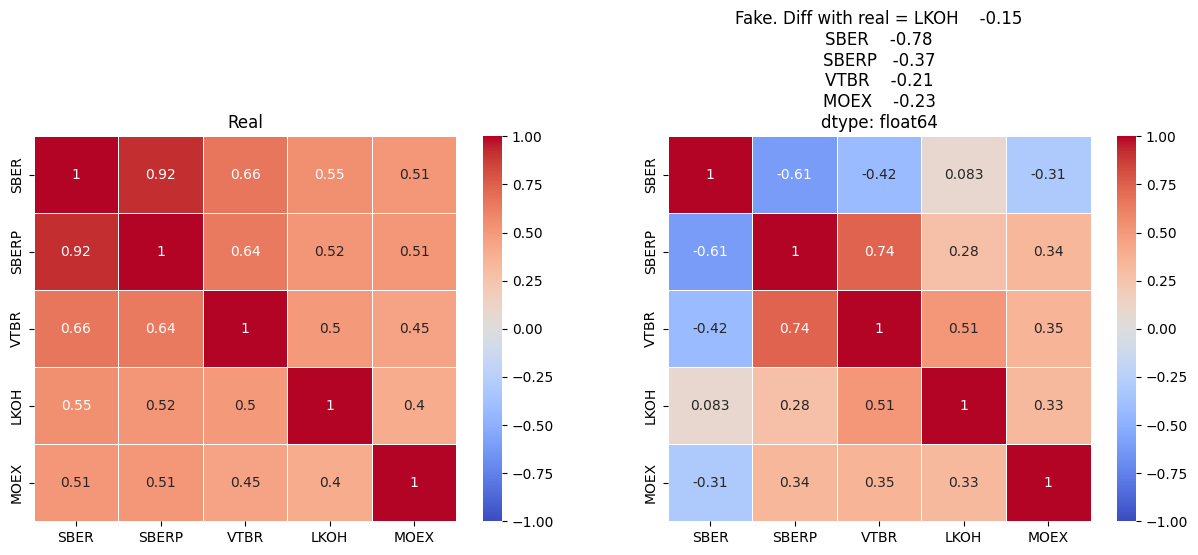

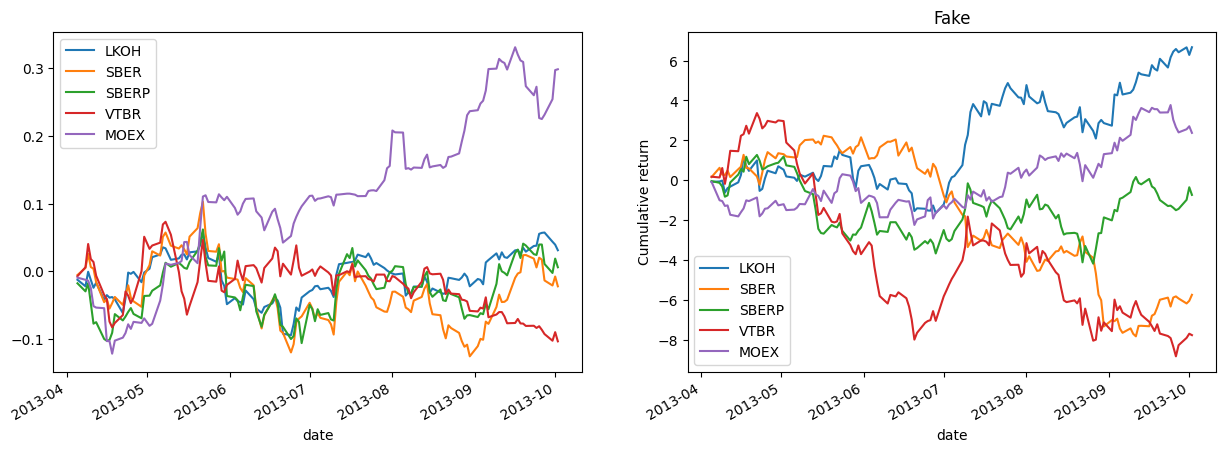

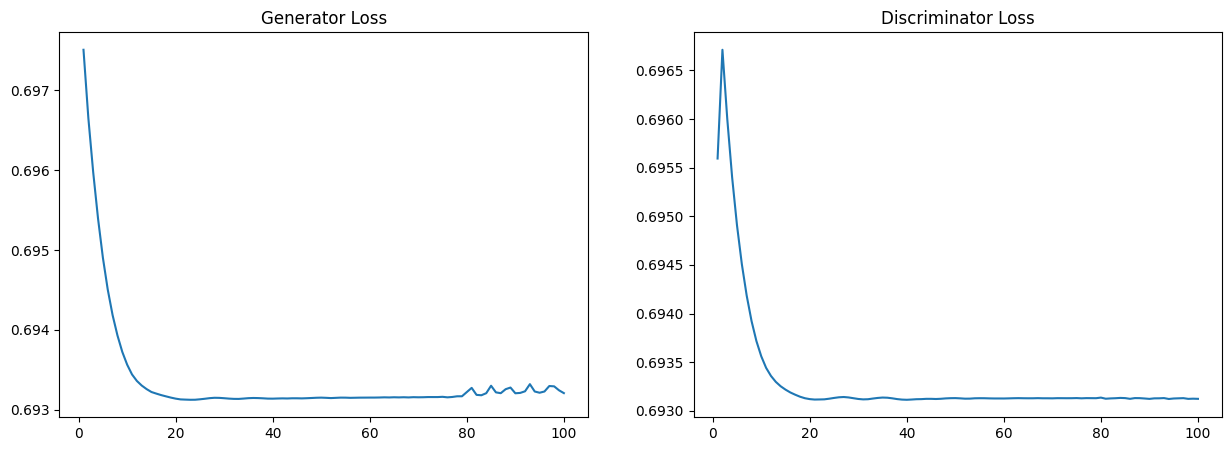

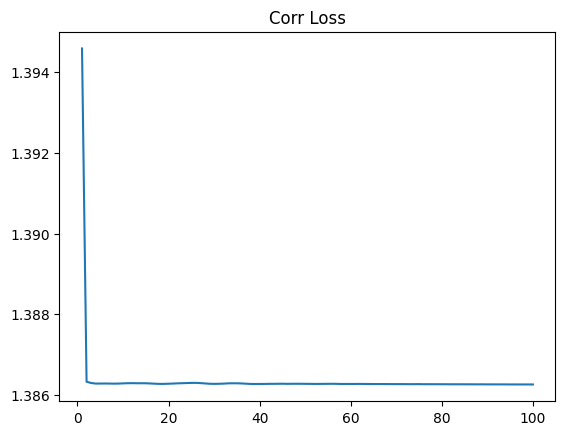

correlation_delta,▇█▅█▇▇▇▆█▆▇▇▇▇▆▇▇▆▇▆▆▅▇▅▅▅▄▅▅▅▄▅▃▂▂▃▃▃▂▁
fid,█▃▃▂▄▄▅▅▂▂▂▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
mean_delta,█▆▆▄▅▇▅▄▄▃▄▄▄▄▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_disc_loss,█▇▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_gen_loss,█▅▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
correlation_delta,0.35284
fid,3.58933
mean_delta,0.00554
train_disc_loss,0.69312
train_gen_loss,0.69321


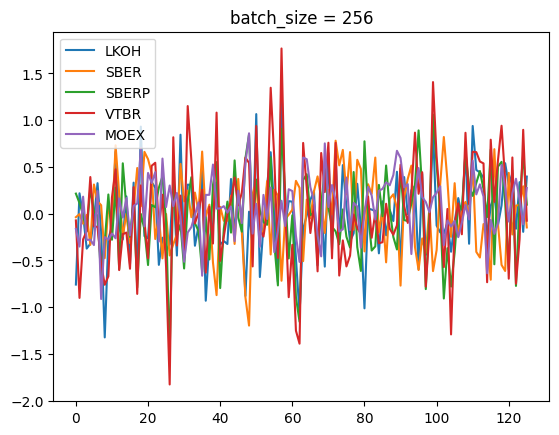

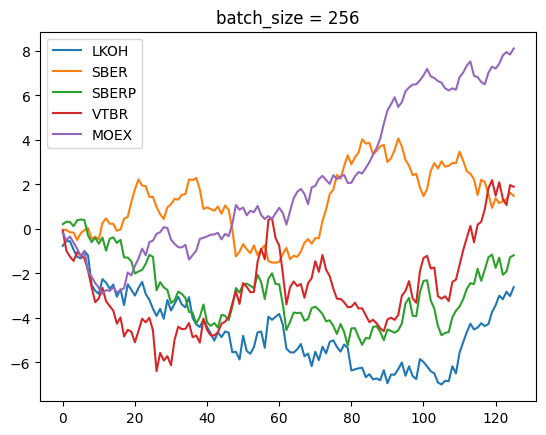

In [78]:
from library.gan_train_loop import train_gan

N_EPOCHS = 100
LOG_FREQUENCY = 100
SAVE_FREQUENCY = 300
LR = 0.0002
KERNEL_SIZE=5
window_size = WINDOW_SIZE

torch.manual_seed(1) # фиксим рандомайзеры

wandb.init(
                project="gan_moex",  # Название проекта в W&B
                name=f"MAKSIM генерация log доходности акций",         # MAKSIM генерация log доходности акций
                
                config={              # Сохраняем гиперпараметры
                    "learning_rate": LR,
                    "batch_size": BATCH_SIZE,
                    "architecture": "TCN-GAN Maksim",
                    "dataset": "log-returns",
                    "kernel_size": KERNEL_SIZE,
                    "N_EPOCHS": N_EPOCHS,
                    "window_size": window_size,
                }
            )
    

# for kernel_size in [2]:
    # Define generator and discriminator
discriminator = Discriminator().to(DEVICE)
generator = Generator(KERNEL_SIZE).to(DEVICE)

# Define the optimizers for generator and discriminator
generator_optimizer = optim.RMSprop(generator.parameters(), lr=LR)
discriminator_optimizer = optim.RMSprop(discriminator.parameters(), lr=LR)
# Train GAN
generator_losses, discriminator_losses_real, discriminator_losses_fake = train_gan(
        generator, 
        discriminator, 
        generator_optimizer, 
        discriminator_optimizer, 
        dataloader, 
        df_returns_real, 
        n_epochs=N_EPOCHS, 
        log_frequency=LOG_FREQUENCY, 
        save_frequency=SAVE_FREQUENCY, 
        model_prefix='TCN')


samples = generate_samples(generator, dataloader.dataset.assets)
samples.plot()
plt.title(f'batch_size = {BATCH_SIZE}')
wandb.log({"generated_samples": wandb.Image(plt)})


samples.cumsum().plot()
plt.title(f'batch_size = {BATCH_SIZE}')
wandb.log({"cumsum_generated_samples": wandb.Image(plt)})

wandb.finish()


In [16]:

my_df_returns_fake = generate_fake_returns(generator, df_returns_real, seed=0)


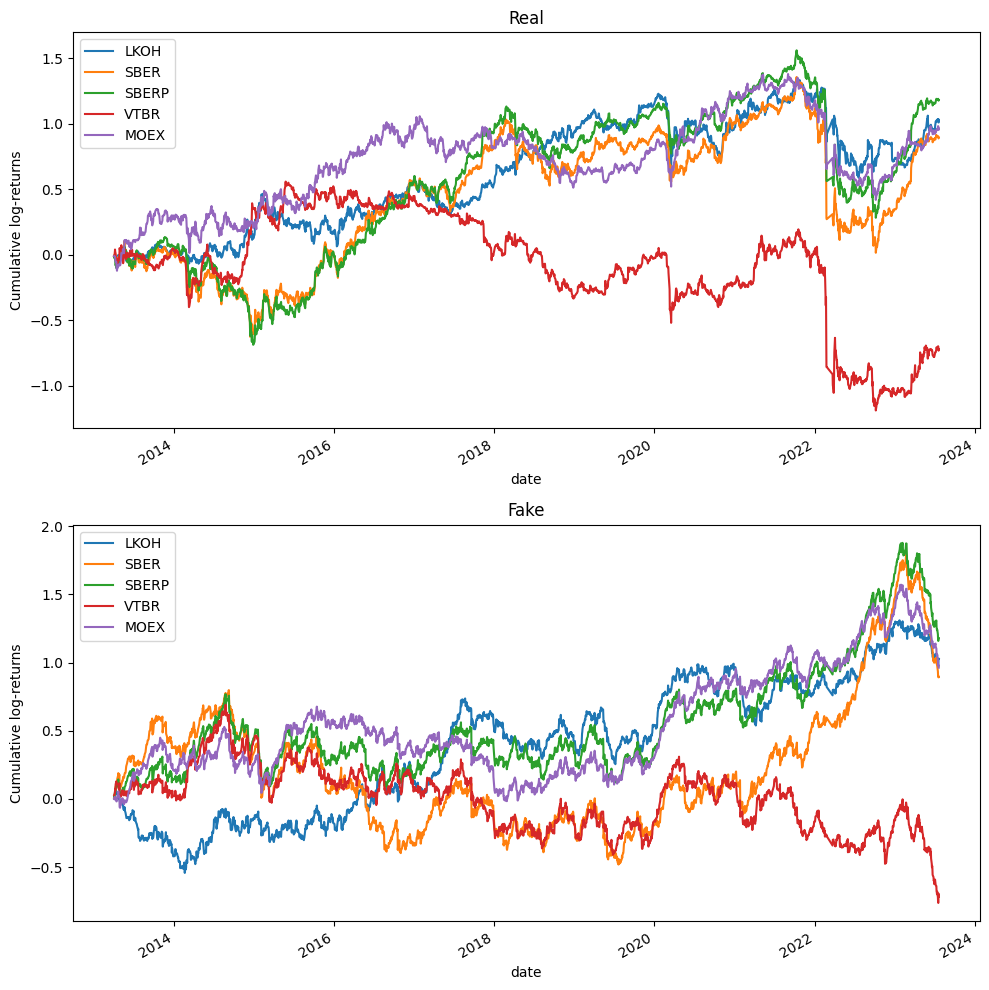

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

plt.subplot(2, 1, 1)

df_returns_real.cumsum().plot(ax=ax1)
plt.title('Real')
plt.ylabel('Cumulative log-returns')

plt.subplot(2, 1, 2)
my_df_returns_fake.cumsum().plot(ax=ax2)
plt.title('Fake')
plt.ylabel('Cumulative log-returns')
plt.tight_layout()

plt.show()

In [21]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

def check_basic_stats(returns):
    """Проверка базовых статистических свойств"""
    statistic = {
        'Mean': returns.mean(),
        'Volatility': returns.std(),
        'Skewness': returns.skew(),
        'Kurtosis': returns.kurtosis(),
        'Shapiro-Wilk p-value': stats.shapiro(returns)[1],
        'JB-test p-value': stats.jarque_bera(returns)[1]
    }
    
    # Q-Q plot
    plt.figure(figsize=(10, 6))
    stats.probplot(returns, dist="norm", plot=plt)
    plt.title('Q-Q Plot')
    plt.show()
    
    return pd.DataFrame(statistic, index=['Value'])

In [16]:

from numpy.lib.stride_tricks import sliding_window_view

def asset_windowed_correlation(df, lag, window_size):
    """
    Вычисляет корреляцию между окнами для каждой акции отдельно.
    
    Параметры:
        df: pd.DataFrame, где каждый столбец - временной ряд актива
        lag: int, расстояние между окнами (lag >= window_size)
        window_size: int, размер окна
    
    Возвращает:
        dict: {название_акции: np.array корреляций}
    """
    if lag < window_size:
        raise ValueError("lag должен быть >= window_size")
    
    results = {}
    
    for asset in df.columns:
        series = df[asset].values
        n = len(series)
        
        # Создаем sliding windows
        windows = sliding_window_view(series, window_shape=window_size)
        windows1 = windows[:-lag]  # Первые окна
        windows2 = windows[lag:]   # Вторые окна
        
        # Центрируем и нормируем
        w1_centered = windows1 - windows1.mean(axis=1, keepdims=True)
        w2_centered = windows2 - windows2.mean(axis=1, keepdims=True)
        
        # Вычисляем корреляции
        cov = np.sum(w1_centered * w2_centered, axis=1)
        std1 = np.sqrt(np.sum(w1_centered**2, axis=1))
        std2 = np.sqrt(np.sum(w2_centered**2, axis=1))
        
        correlations = cov / (std1 * std2)
        results[asset] = correlations
    return pd.DataFrame(results)

In [76]:
corr = pd.DataFrame()
for lag in range(50, 400, 5):
    print(lag)
    for win in range(10, min(200, lag), 5):
        a = asset_windowed_correlation(df_returns_real.cumsum(), lag, win)
        sum_corr = a.sum()
        
        temp = pd.DataFrame()
        temp['lag'] = [lag]
        temp['window_size'] = [win]
        
        temp['corr_SBER'] = sum_corr['SBER']
        temp['corr_SBERP'] = sum_corr['SBERP']
        temp['corr_LKOH'] = sum_corr['LKOH']
        temp['corr_VTBR'] = sum_corr['VTBR']
        temp['corr_MOEX'] = sum_corr['MOEX']
        corr = pd.concat([corr, temp])

50
55
60
65
70
75
80
85
90
95
100
105
110
115
120
125
130
135
140
145
150
155
160
165
170
175
180
185
190
195
200
205
210
215
220
225
230
235
240
245
250
255
260
265
270
275
280
285
290
295
300
305
310
315
320
325
330
335
340
345
350
355
360
365
370
375
380
385
390
395


In [67]:
corr

,lag,window_size,corr_SBER,corr_SBERP,corr_LKOH,corr_VTBR,corr_MOEX
0,50,10,94.815428,112.315526,40.321407,-27.088661,167.771261
0,50,15,158.346980,168.207257,68.770990,-53.774323,208.536016
0,50,20,212.432014,213.837592,91.877511,-82.373374,234.628129
0,50,25,252.596399,258.833131,113.825812,-114.539173,247.203647
0,50,30,276.840541,294.892950,129.483320,-139.795674,260.730697
...,...,...,...,...,...,...,...
0,195,170,-197.120476,-104.164938,-76.464829,-129.948763,104.007401
0,195,175,-202.301601,-107.501974,-84.899966,-133.955062,107.314554
0,195,180,-206.877448,-110.519465,-92.788437,-137.328607,110.357148
0,195,185,-210.691129,-113.114174,-100.340110,-140.252442,113.160807


In [77]:

corr_matrix = corr.pivot(index='window_size', 
                              columns='lag')
corr_matrix

corr_SBER                                                  \
lag                 50          55          60          65          70    
window_size                                                               
10            94.815428  114.730732  -12.012760   24.141923   63.566036   
15           158.346980  156.839578   -3.429856   14.278694   85.101885   
20           212.432014  182.306491   18.768029   26.437046   88.542881   
25           252.596399  200.718886   44.766092   39.256958   78.520865   
30           276.840541  217.319390   71.508870   52.023383   66.298787   
35           289.034279  230.669275   96.505613   68.777009   67.928467   
40           290.785505  235.254427  111.906014   84.587286   74.952609   
45           289.011899  233.177383  120.339870   98.461788   84.274661   
50                  NaN  226.540346  124.365411  110.839810   97.271504   
55                  NaN         NaN  129.183625  124.477080  112.674193   
60                  NaN         NaN         NaN  139.684258  128.855734   
65                  NaN         NaN         NaN         NaN  144.575429   
70                  NaN         NaN         NaN         NaN         NaN   
75                  NaN         NaN         NaN         NaN         NaN   
80                  NaN         NaN         NaN         NaN         NaN   
85                  NaN         NaN         NaN         NaN         NaN   
90                  NaN         NaN         NaN         NaN         NaN   
95                  NaN         NaN         NaN         NaN         NaN   
100                 NaN         NaN         NaN         NaN         NaN   
105                 NaN         NaN         NaN         NaN         NaN   
110                 NaN         NaN         NaN         NaN         NaN   
115                 NaN         NaN         NaN         NaN         NaN   
120                 NaN         NaN         NaN         NaN         NaN   
125                 NaN         NaN         NaN         NaN         NaN   
130                 NaN         NaN         NaN         NaN         NaN   
135                 NaN         NaN         NaN         NaN         NaN   
140                 NaN         NaN         NaN         NaN         NaN   
145                 NaN         NaN         NaN         NaN         NaN   
150                 NaN         NaN         NaN         NaN         NaN   
155                 NaN         NaN         NaN         NaN         NaN   
160                 NaN         NaN         NaN         NaN         NaN   
165                 NaN         NaN         NaN         NaN         NaN   
170                 NaN         NaN         NaN         NaN         NaN   
175                 NaN         NaN         NaN         NaN         NaN   
180                 NaN         NaN         NaN         NaN         NaN   
185                 NaN         NaN         NaN         NaN         NaN   
190                 NaN         NaN         NaN         NaN         NaN   
195                 NaN         NaN         NaN         NaN         NaN   

                                                                         ...  \
lag                 75          80          85          90          95   ...   
window_size                                                              ...   
10            92.627036  -16.185574 -115.258474   31.095791   67.877664  ...   
15           111.082750   -7.909050 -108.099956   56.457827  101.197391  ...   
20           101.266454  -13.051740  -89.061617   62.125598  123.055227  ...   
25            84.918404  -16.806508  -73.996189   64.012000  138.817424  ...   
30            70.591382  -13.299983  -53.558746   72.200741  153.233921  ...   
35            65.269550   -0.312027  -26.379871   85.906865  164.861940  ...   
40            67.034637   15.858358   -2.348573   97.453883  168.872222  ...   
45            72.008362   28.552715   14.626314  105.058370  168.770795  ...   
50            81.562032   40.208633   27.275322  108.35194

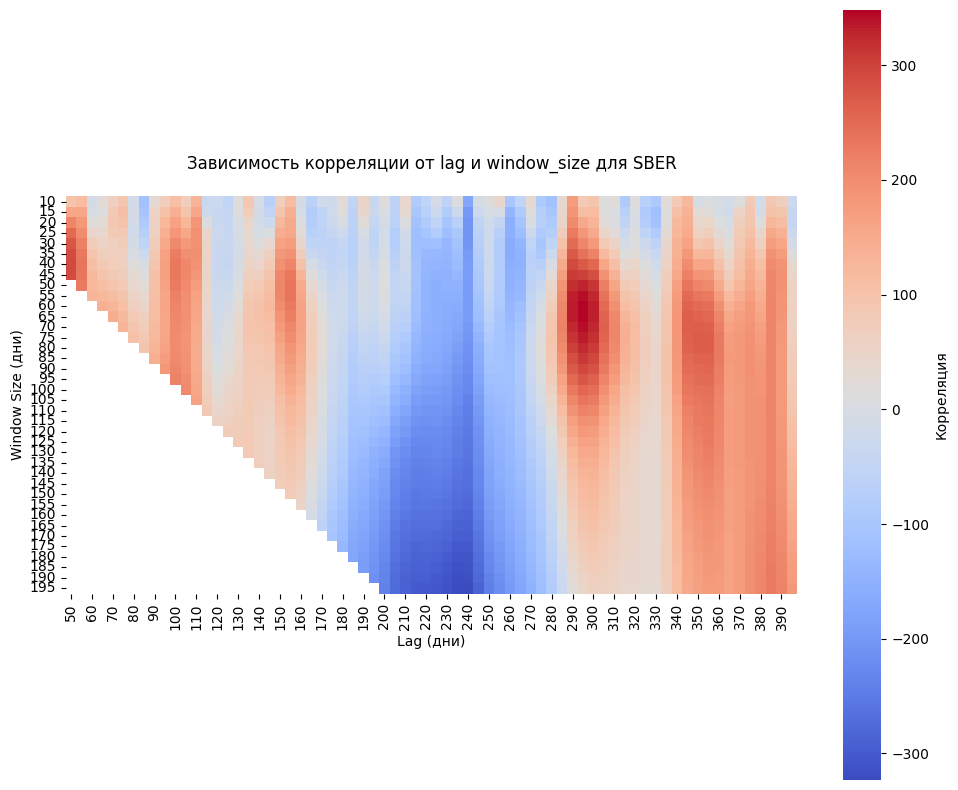

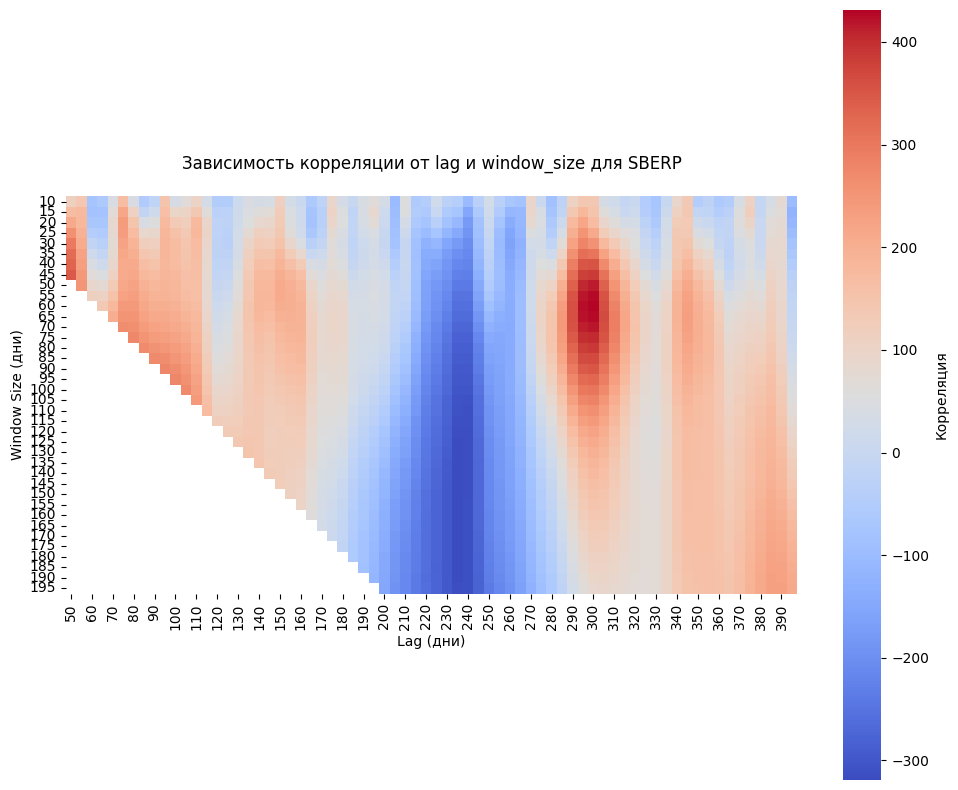

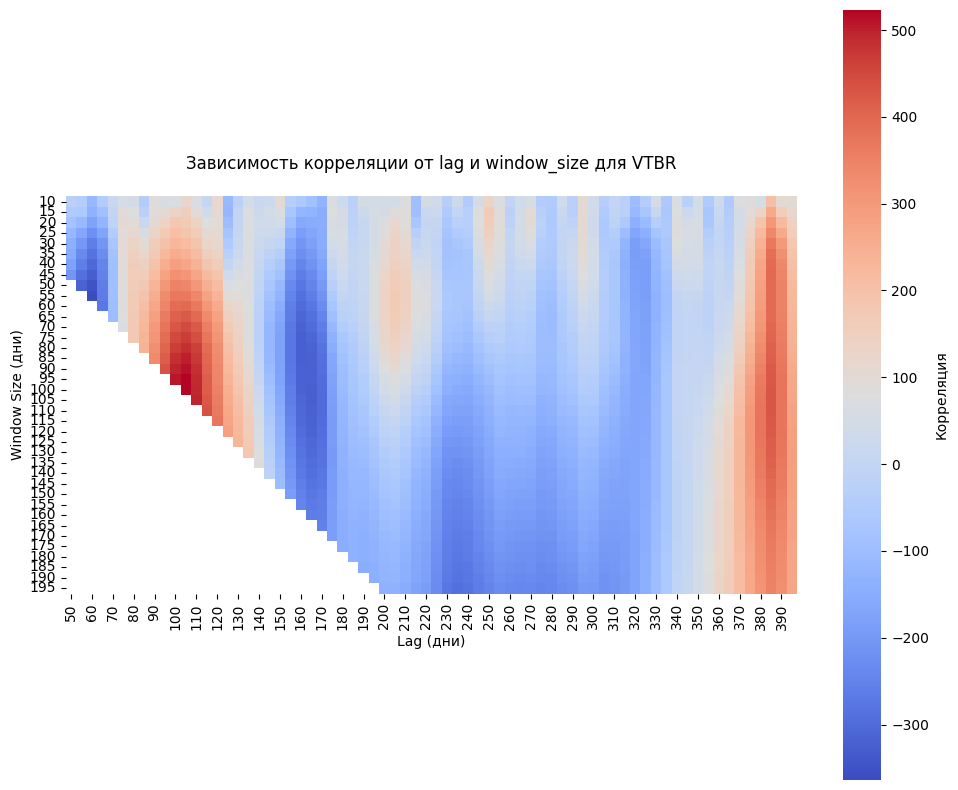

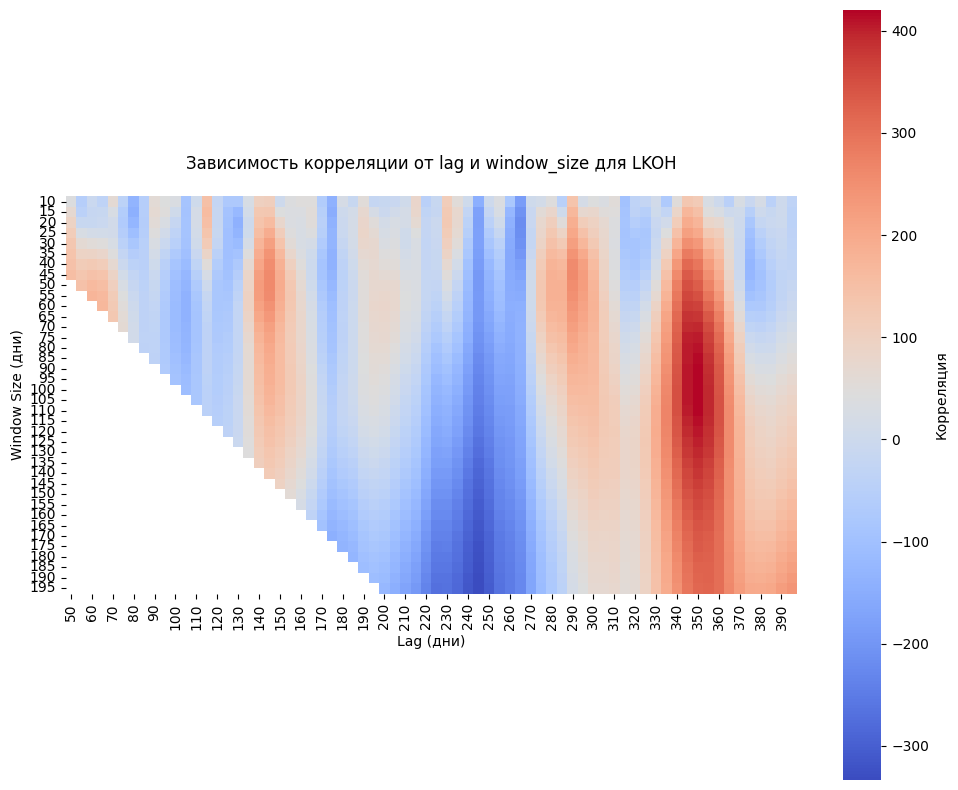

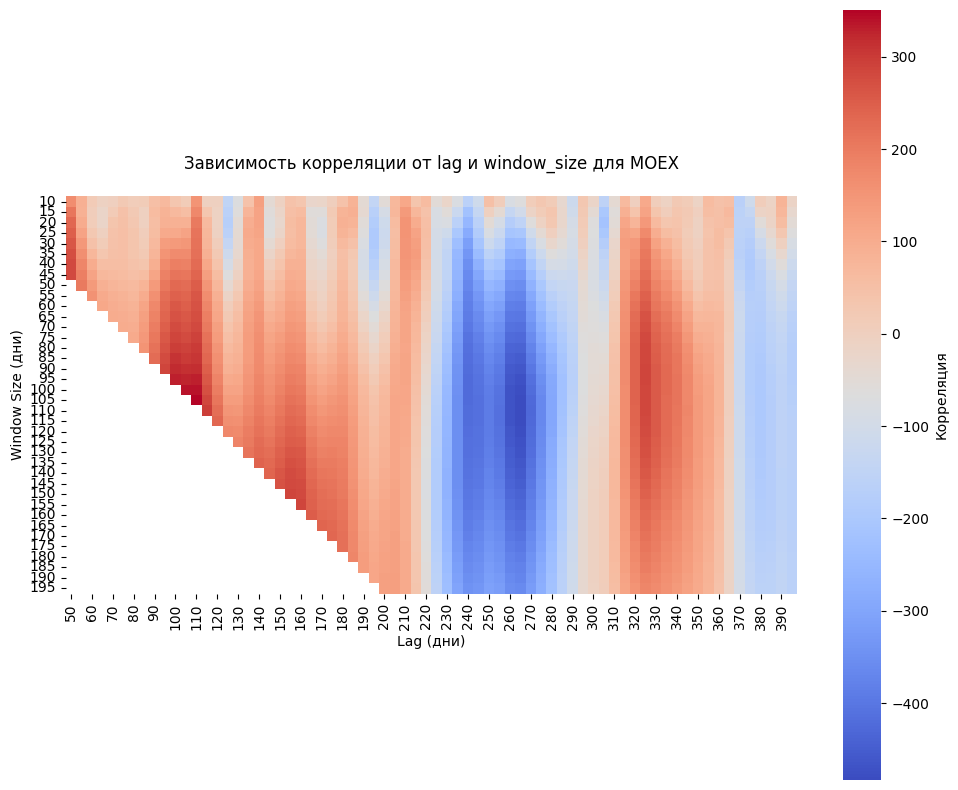

In [79]:
for name in ('SBER', 'SBERP', 'VTBR', 'LKOH', 'MOEX'):
    print
    # Строим heatmap без аннотаций
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix[f'corr_{name}'],
                cmap="coolwarm",
                cbar_kws={'label': 'Корреляция'},
                square=True,
                annot=False)  # Отключаем цифры
    
    # Настройки отображения
    plt.title(f"Зависимость корреляции от lag и window_size для {name}", pad=20)
    plt.xlabel("Lag (дни)")
    plt.ylabel("Window Size (дни)")
    plt.tight_layout()
    plt.show()